In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
!pip -q install scipy
!pip -q install scipy shap xgboost

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_rel

import shap
shap.initjs()


#Data Loading

In [63]:
df_2021 = pd.read_excel("/content/drive/MyDrive/Projects/Ridika_Project/All Genre 2021(1).xlsx")
df_2022 = pd.read_csv("/content/drive/MyDrive/Projects/Ridika_Project/All genr 2022.csv")

df_2021["Year"] = 2021
df_2022["Year"] = 2022

df = pd.concat([df_2021, df_2022], ignore_index=True)
df.columns = df.columns.str.strip()
df.head()


,Movie_Name,Rating,Total_Numberof_Rating,Runtime,Metascore,Year,Rating_latter,Genre
0,Nobody,7.4,359000,92.0,64.0,2021,R,Action
1,The Suicide Squad,7.2,439000,132.0,72.0,2021,R,Action
2,Spider-Man: No Way Home,8.2,967000,148.0,71.0,2021,PG-13,Action
3,Dune: Part One,8.0,970000,155.0,74.0,2021,PG-13,Action
4,Zack Snyder's Justice League,7.9,461000,242.0,54.0,2021,R,Action


#Data Before Preprocessing

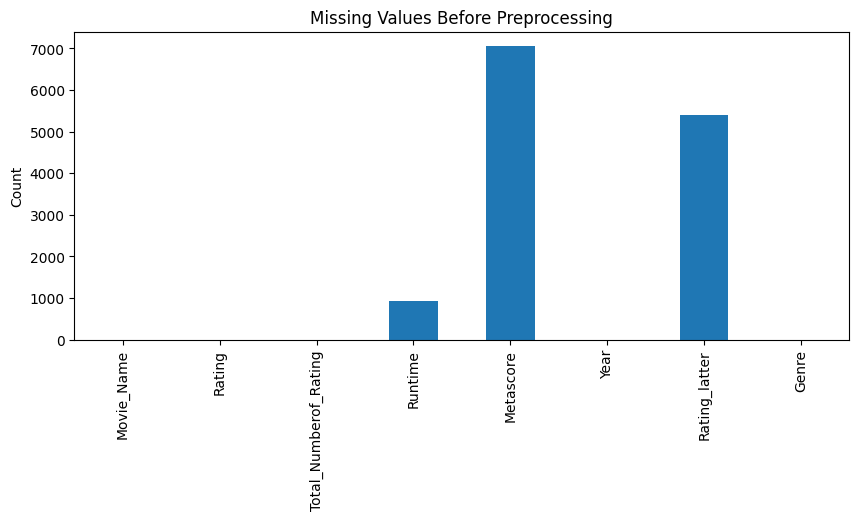

In [64]:
plt.figure(figsize=(10,4))
df.isnull().sum().plot(kind="bar")
plt.title("Missing Values Before Preprocessing")
plt.ylabel("Count")
plt.show()


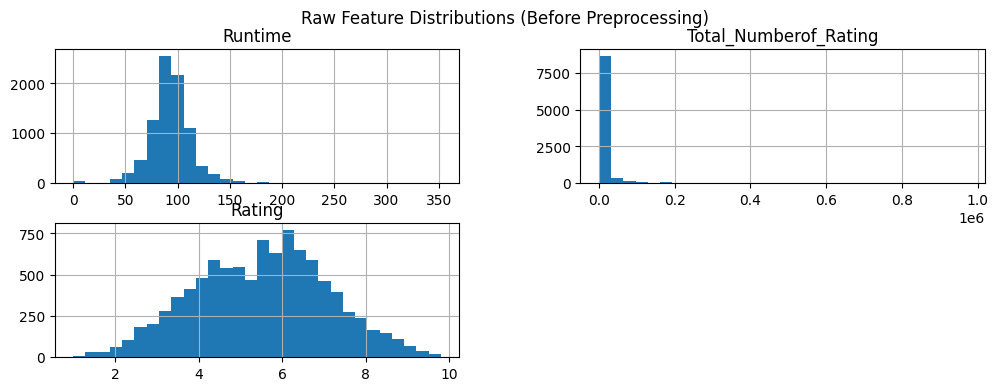

In [65]:
df[["Runtime", "Total_Numberof_Rating", "Rating"]].hist(bins=30, figsize=(12,4))
plt.suptitle("Raw Feature Distributions (Before Preprocessing)")
plt.show()


#Preprocessing

In [66]:
for col in ["Year", "Runtime", "Total_Numberof_Rating", "Rating"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Movie_Name", "Rating"])
df.isnull().sum()


,0
Movie_Name,0
Rating,0
Total_Numberof_Rating,0
Runtime,928
Metascore,7050
Year,0
Rating_latter,5409
Genre,0


In [67]:
df["Genre"] = df["Genre"].fillna("Unknown")

# Runtime
df["Runtime"] = df.groupby("Genre")["Runtime"].transform(lambda x: x.fillna(x.median()))
df["Runtime"] = df["Runtime"].fillna(df["Runtime"].median())

# Rating_latter
df["Rating_latter"] = df.groupby("Genre")["Rating_latter"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)
df["Rating_latter"] = df["Rating_latter"].fillna("Unknown")

# Total ratings (log-scaled)
df["Total_Numberof_Rating"] = df.groupby("Genre")["Total_Numberof_Rating"].transform(
    lambda x: x.fillna(x.median())
)
df["Total_Numberof_Rating"] = df["Total_Numberof_Rating"].fillna(df["Total_Numberof_Rating"].median())
df["Total_Numberof_Rating"] = np.log1p(df["Total_Numberof_Rating"])

df.isnull().sum()


,0
Movie_Name,0
Rating,0
Total_Numberof_Rating,0
Runtime,0
Metascore,7050
Year,0
Rating_latter,0
Genre,0


#METASCORE IMPUTATION

In [68]:
# Ensure numeric
df["Metascore"] = pd.to_numeric(df["Metascore"], errors="coerce")

# Fill Metascore using genre-wise median
df["Genre"] = df["Genre"].fillna("Unknown")

df["Metascore"] = df.groupby("Genre")["Metascore"].transform(
    lambda x: x.fillna(x.median())
)
#Genre Missing
df["Metascore"] = df["Metascore"].fillna(df["Metascore"].median())

# Verify
df["Metascore"].isnull().sum()


np.int64(0)

In [69]:
df.isnull().sum()

,0
Movie_Name,0
Rating,0
Total_Numberof_Rating,0
Runtime,0
Metascore,0
Year,0
Rating_latter,0
Genre,0


#Data Quality After Preprocessing

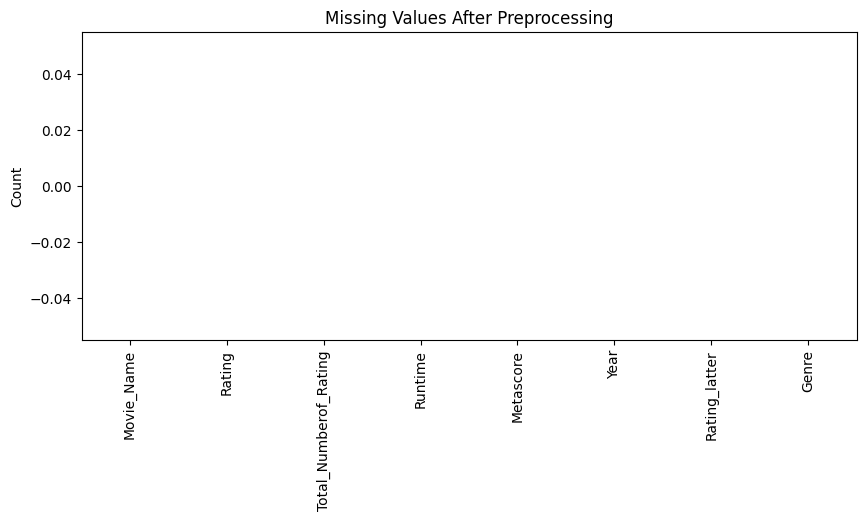

In [70]:
plt.figure(figsize=(10,4))
df.isnull().sum().plot(kind="bar")
plt.title("Missing Values After Preprocessing")
plt.ylabel("Count")
plt.show()


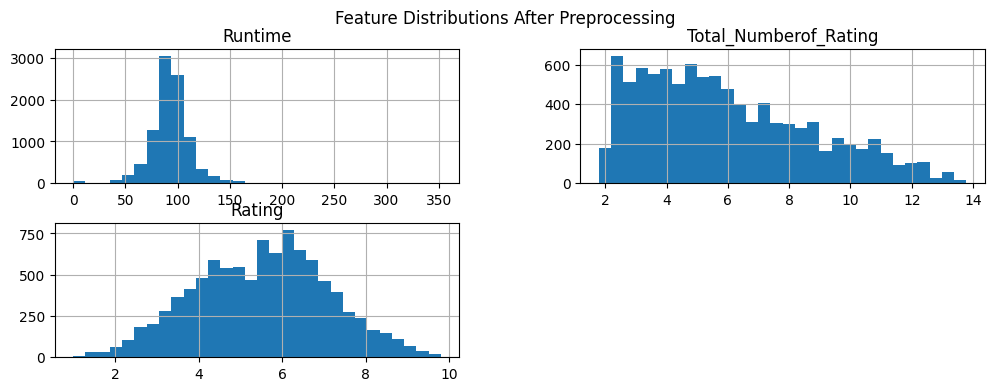

In [71]:
df[["Runtime", "Total_Numberof_Rating", "Rating"]].hist(bins=30, figsize=(12,4))
plt.suptitle("Feature Distributions After Preprocessing")
plt.show()


#Feature Step

In [72]:
features = ["Genre", "Runtime", "Rating_latter", "Year", "Total_Numberof_Rating"]
target = "Rating"

categorical_features = ["Genre", "Rating_latter"]
numeric_features = ["Runtime", "Year", "Total_Numberof_Rating"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features)
])


#Splitting

In [73]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df[features]
y = df[target]

# 80% train, 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

len(X_train), len(X_test)


(7640, 1911)

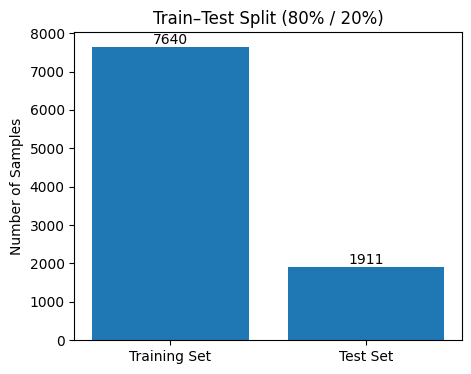

In [74]:
# -------- TRAIN vs TEST SIZE BAR CHART --------

sizes = [len(X_train), len(X_test)]
labels = ["Training Set", "Test Set"]

plt.figure(figsize=(5,4))
plt.bar(labels, sizes)
plt.ylabel("Number of Samples")
plt.title("Train–Test Split (80% / 20%)")

# Add value labels on bars
for i, v in enumerate(sizes):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.show()


#Model Implementation

In [75]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds),
        "preds": preds
    }

pd.DataFrame(results).T.sort_values("RMSE")


,RMSE,MAE,R2,preds
RandomForest,1.21337,0.878307,0.416742,"[3.572000000000004, 6.101749999999995, 3.72599..."
Ridge,1.486888,1.198061,0.124148,"[5.17946011768941, 5.603358652020838, 5.126617..."
Linear,1.487165,1.198222,0.123821,"[5.179184906093017, 5.602350034634959, 5.12708..."
ElasticNet,1.493926,1.210156,0.115836,"[5.291539949548875, 5.632752507874126, 5.17192..."
Lasso,1.499452,1.215008,0.109283,"[5.362789451787861, 5.647498059655582, 5.19190..."


#RMSE Bar Chart

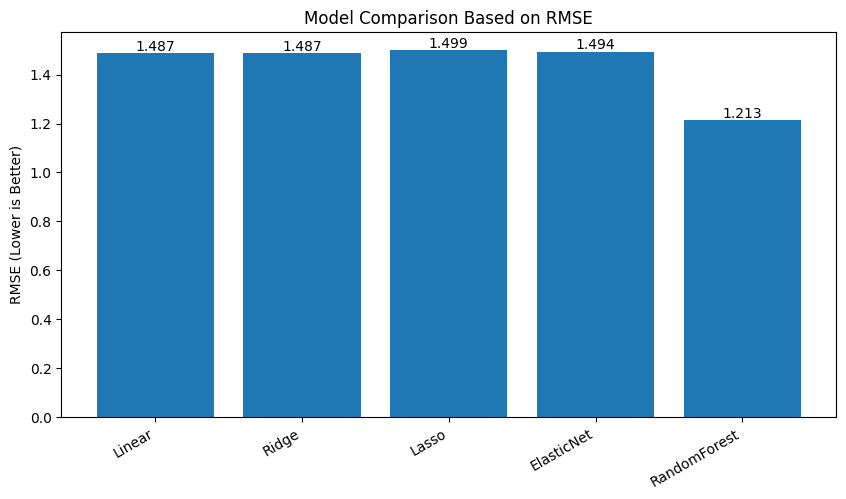

In [76]:
model_names = list(results.keys())
rmse_values = [results[m]["RMSE"] for m in model_names]

plt.figure(figsize=(10,5))
plt.bar(model_names, rmse_values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSE (Lower is Better)")
plt.title("Model Comparison Based on RMSE")

# value labels
for i, v in enumerate(rmse_values):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.show()


#MAE Bar CHart

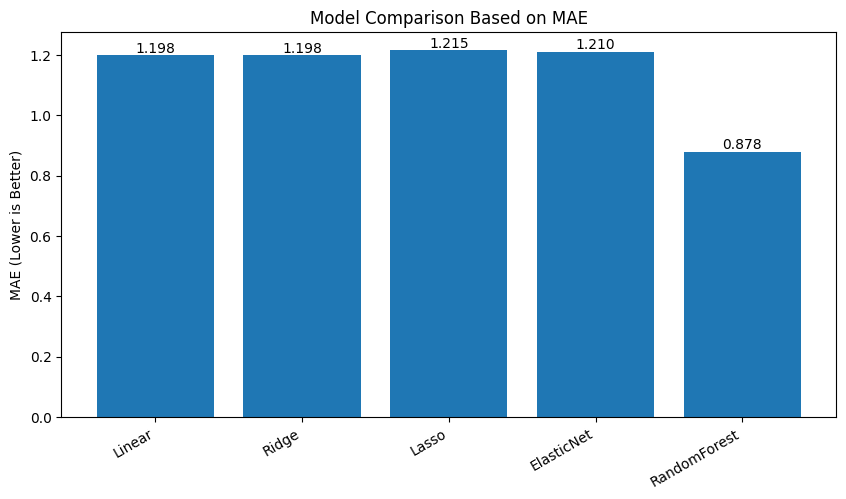

In [77]:
# -------- MAE COMPARISON --------

mae_values = [results[m]["MAE"] for m in model_names]

plt.figure(figsize=(10,5))
plt.bar(model_names, mae_values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("MAE (Lower is Better)")
plt.title("Model Comparison Based on MAE")

# value labels
for i, v in enumerate(mae_values):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.show()


#R2 COmparison

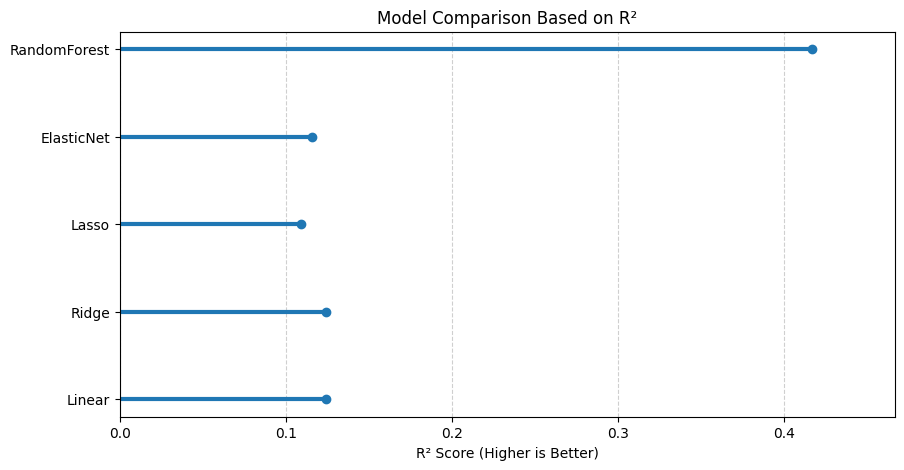

In [78]:
# -------- R² LOLLIPOP PLOT --------

r2_values = [results[m]["R2"] for m in model_names]

plt.figure(figsize=(10,5))
plt.hlines(
    y=model_names,
    xmin=0,
    xmax=r2_values,
    linewidth=3
)
plt.plot(
    r2_values,
    model_names,
    "o"
)

plt.xlabel("R² Score (Higher is Better)")
plt.title("Model Comparison Based on R²")
plt.xlim(0, max(r2_values) + 0.05)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()


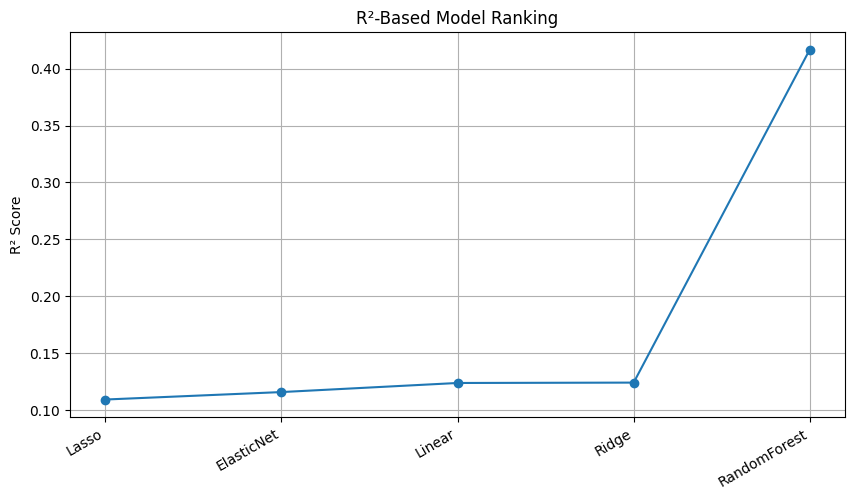

In [79]:
sorted_models = sorted(results.items(), key=lambda x: x[1]["R2"])
sorted_names = [m[0] for m in sorted_models]
sorted_r2 = [m[1]["R2"] for m in sorted_models]

plt.figure(figsize=(10,5))
plt.plot(sorted_names, sorted_r2, marker="o")
plt.xticks(rotation=30, ha="right")
plt.ylabel("R² Score")
plt.title("R²-Based Model Ranking")
plt.grid(True)
plt.show()


#XGboost

In [80]:
xgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    ))
])

xgb_pipe.fit(X_train, y_train)
xgb_preds = xgb_pipe.predict(X_test)

results["XGBoost"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, xgb_preds)),
    "MAE": mean_absolute_error(y_test, xgb_preds),
    "R2": r2_score(y_test, xgb_preds),
    "preds": xgb_preds
}

pd.DataFrame(results).T.sort_values("RMSE")


,RMSE,MAE,R2,preds
XGBoost,1.209378,0.916597,0.420573,"[3.88595, 6.3031173, 4.2240176, 4.1980777, 5.9..."
RandomForest,1.21337,0.878307,0.416742,"[3.572000000000004, 6.101749999999995, 3.72599..."
Ridge,1.486888,1.198061,0.124148,"[5.17946011768941, 5.603358652020838, 5.126617..."
Linear,1.487165,1.198222,0.123821,"[5.179184906093017, 5.602350034634959, 5.12708..."
ElasticNet,1.493926,1.210156,0.115836,"[5.291539949548875, 5.632752507874126, 5.17192..."
Lasso,1.499452,1.215008,0.109283,"[5.362789451787861, 5.647498059655582, 5.19190..."


#XGBOOST: PREDICTED vs ACTUAL

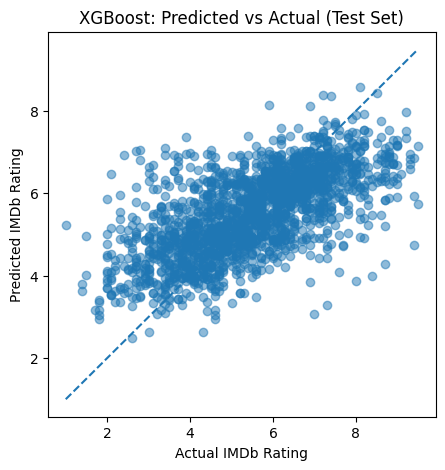

In [81]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, xgb_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("XGBoost: Predicted vs Actual (Test Set)")
plt.show()


#XGBOOST: RESIDUAL PLOT

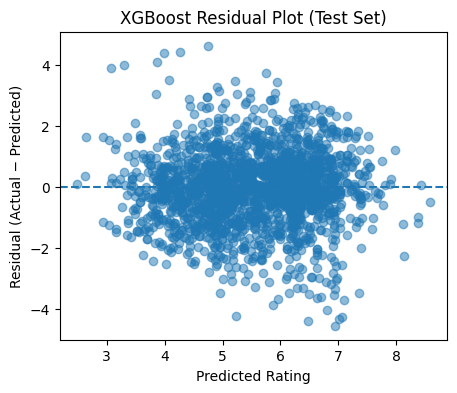

In [82]:
xgb_residuals = y_test - xgb_preds

plt.figure(figsize=(5,4))
plt.scatter(xgb_preds, xgb_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Rating")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("XGBoost Residual Plot (Test Set)")
plt.show()


#Hybrid Proposed Model

#ENSEMBLE MODEL: RF + XGBOOST

In [84]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# RANDOM FOREST (TUNED)
rf_pipe_ens = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=400,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe_ens.fit(X_train, y_train)
rf_preds_ens = rf_pipe_ens.predict(X_test)

# XGBOOST (TUNED)
xgb_pipe_ens = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe_ens.fit(X_train, y_train)
xgb_preds_ens = xgb_pipe_ens.predict(X_test)

# ENSEMBLE PREDICTIONS
ensemble_avg_preds = (rf_preds_ens + xgb_preds_ens) / 2
ensemble_weighted_preds = (0.6 * xgb_preds_ens) + (0.4 * rf_preds_ens)

#  EVALUATION
def eval_model(name, preds):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }

ensemble_results = {
    "RandomForest_Tuned": eval_model("RF", rf_preds_ens),
    "XGBoost_Tuned": eval_model("XGB", xgb_preds_ens),
    "Ensemble_Average": eval_model("ENS_AVG", ensemble_avg_preds),
    "Ensemble_Weighted": eval_model("ENS_W", ensemble_weighted_preds)
}

pd.DataFrame(ensemble_results).T.sort_values("RMSE")


,RMSE,MAE,R2
Ensemble_Average,1.197978,0.904267,0.431445
Ensemble_Weighted,1.198300,0.905906,0.431140
XGBoost_Tuned,1.206981,0.918450,0.422868
RandomForest_Tuned,1.207468,0.904616,0.422401


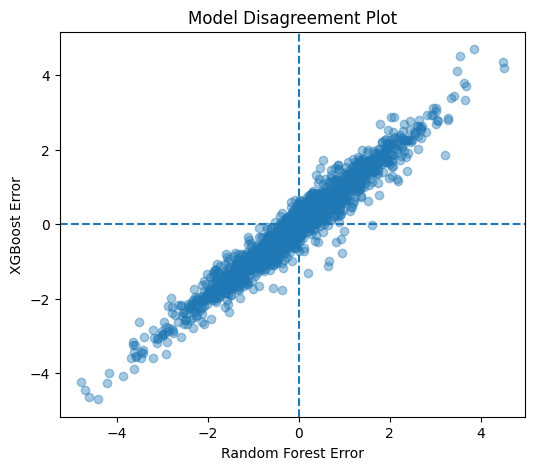

In [85]:
# WHERE MODELS DISAGREE
rf_errors = y_test - rf_preds_ens
xgb_errors = y_test - xgb_preds_ens

plt.figure(figsize=(6,5))
plt.scatter(rf_errors, xgb_errors, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Random Forest Error")
plt.ylabel("XGBoost Error")
plt.title("Model Disagreement Plot")

plt.show()


# COMPARISON TABLE

In [86]:
combined_results = {}

# Existing models
for k, v in results.items():
    combined_results[k] = {
        "RMSE": v["RMSE"],
        "MAE": v["MAE"],
        "R2": v["R2"]
    }

# Ensemble models
for k, v in ensemble_results.items():
    combined_results[k] = v

comparison_df = pd.DataFrame(combined_results).T.sort_values("RMSE")
comparison_df


,RMSE,MAE,R2
Ensemble_Average,1.197978,0.904267,0.431445
Ensemble_Weighted,1.198300,0.905906,0.431140
XGBoost_Tuned,1.206981,0.918450,0.422868
RandomForest_Tuned,1.207468,0.904616,0.422401
XGBoost,1.209378,0.916597,0.420573
RandomForest,1.213370,0.878307,0.416742
Ridge,1.486888,1.198061,0.124148
Linear,1.487165,1.198222,0.123821
ElasticNet,1.493926,1.210156,0.115836
Lasso,1.499452,1.215008,0.109283


In [87]:
best_ensemble_preds = ensemble_weighted_preds


#ENSEMBLE: PREDICTED vs ACTUAL

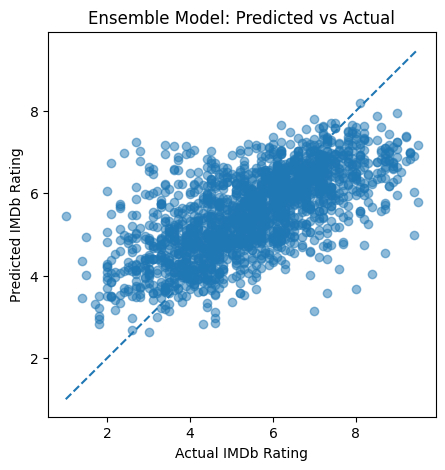

In [88]:

plt.figure(figsize=(5,5))
plt.scatter(y_test, best_ensemble_preds, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("Ensemble Model: Predicted vs Actual")
plt.show()


#RMSE COMPARISON BAR CHART

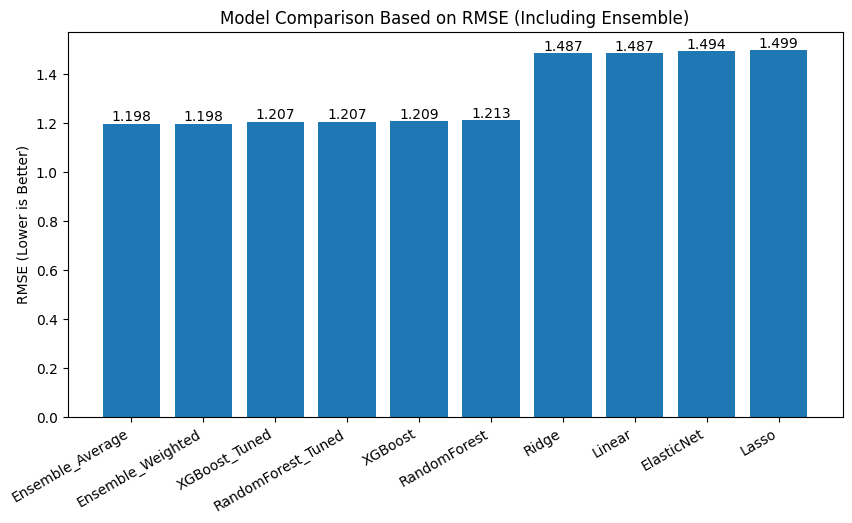

In [89]:
model_names = comparison_df.index.tolist()
rmse_values = comparison_df["RMSE"].values

plt.figure(figsize=(10,5))
plt.bar(model_names, rmse_values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSE (Lower is Better)")
plt.title("Model Comparison Based on RMSE ")

for i, v in enumerate(rmse_values):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.show()


# R² COMPARISON (LOLLIPOP)

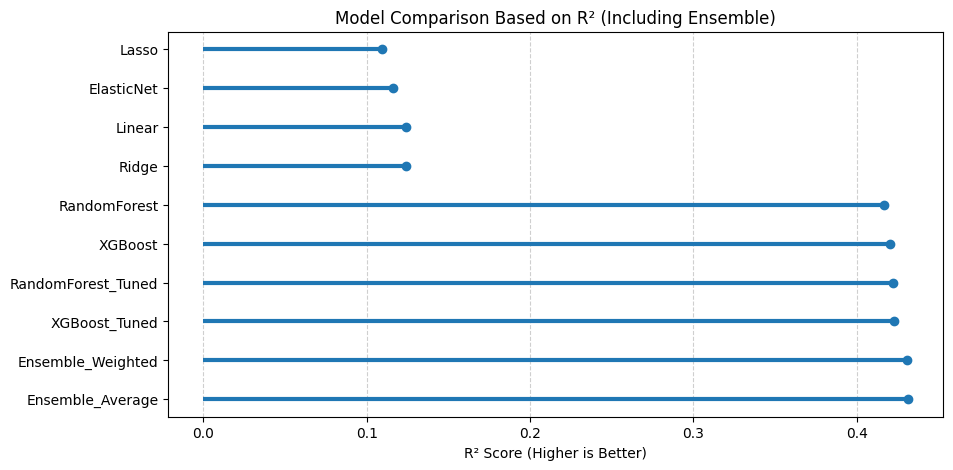

In [90]:
r2_values = comparison_df["R2"].values

plt.figure(figsize=(10,5))
plt.hlines(
    y=model_names,
    xmin=0,
    xmax=r2_values,
    linewidth=3
)
plt.plot(r2_values, model_names, "o")

plt.xlabel("R² Score (Higher is Better)")
plt.title("Model Comparison Based on R² (Including Ensemble)")
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()


#XAI

#SHAP Analysis

In [91]:
import shap
import numpy as np

shap.initjs()

# Transform data using the SAME preprocessor
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

# Convert sparse to dense
if hasattr(X_train_t, "toarray"):
    X_train_t = X_train_t.toarray()
    X_test_t  = X_test_t.toarray()

# Get feature names after encoding
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(
    ["Genre", "Rating_latter"]
)
num_features = ["Runtime", "Year", "Total_Numberof_Rating"]
feature_names = list(cat_features) + num_features

# Extract trained XGBoost model
xgb_model = xgb_pipe_ens.named_steps["model"]

# SHAP explainer
explainer_xgb = shap.TreeExplainer(xgb_model)

# SHAP values
shap_values_xgb = explainer_xgb.shap_values(X_test_t)


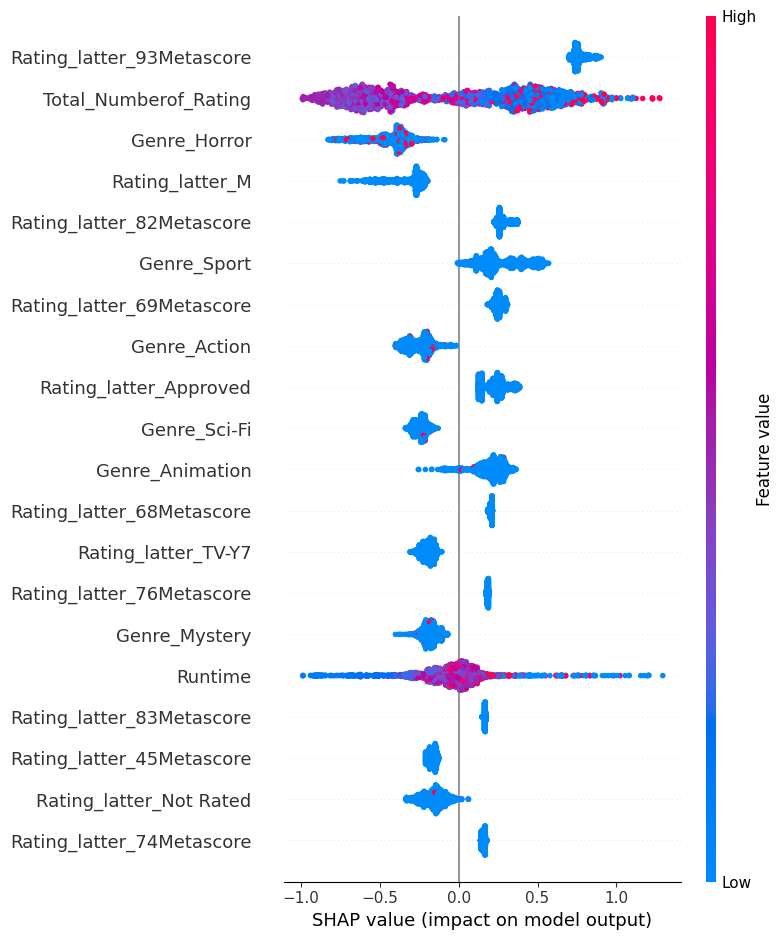

In [92]:
shap.summary_plot(
    shap_values_xgb,
    X_test_t,
    feature_names=feature_names
)


#Inference

In [93]:
def predict_movie_success(
    genre,
    runtime,
    rating_latter,
    year,
    total_number_of_ratings
):
    """
    Predict IMDb rating and classify movie success.
    If any required input is missing or zero, return Flop.
    """

    # -------------------------------
    # INPUT VALIDATION (NEW LOGIC)
    # -------------------------------
    invalid_conditions = (
        genre is None or genre == "" or
        rating_latter is None or rating_latter == "" or
        runtime is None or runtime <= 0 or
        year is None or year <= 0 or
        total_number_of_ratings is None or total_number_of_ratings <= 0
    )

    if invalid_conditions:
        return {
            "Predicted_IMDb_Rating": None,
            "Verdict": "Flop",
            "Reason": "Invalid or missing input values"
        }

    # -------------------------------
    # CREATE INPUT DATAFRAME
    # -------------------------------
    sample = pd.DataFrame([{
        "Genre": genre,
        "Runtime": runtime,
        "Rating_latter": rating_latter,
        "Year": year,
        "Total_Numberof_Rating": np.log1p(total_number_of_ratings)
    }])

    # -------------------------------
    # ENSEMBLE PREDICTION
    # -------------------------------
    rf_pred  = rf_pipe_ens.predict(sample)[0]
    xgb_pred = xgb_pipe_ens.predict(sample)[0]

    final_rating = (0.6 * xgb_pred) + (0.4 * rf_pred)

    # Clamp to IMDb range
    final_rating = float(max(1.0, min(10.0, final_rating)))

    # -------------------------------
    # VERDICT LOGIC
    # -------------------------------
    if final_rating < 5.5:
        verdict = "Flop"
    elif final_rating < 6.4:
        verdict = "Hit"
    else:
        verdict = "Super Hit"

    return {
        "Predicted_IMDb_Rating": round(final_rating, 2),
        "Verdict": verdict
    }


In [95]:
predict_movie_success(
    genre="Adventure",
    runtime=60,
    rating_latter="PG-13",
    year=2021,
    total_number_of_ratings=80000
)



{'Predicted_IMDb_Rating': 6.45, 'Verdict': 'Super Hit'}